# Packages

In [1]:
import sys
sys.path.append('/home/boscoll/github/ReCAST/code')
sys.path.append('/home/boscoll/github/CDKPredict/code')
from ReCAST import ReCAST
import matplotlib as mpl
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import fdrcorrection
from sklearn.metrics import cohen_kappa_score
from sksurv.metrics import concordance_index_censored
from sksurv.metrics import cumulative_dynamic_auc
from helper_functions import *
from pathlib import Path
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = ['Helvetica']
from matplotlib import font_manager
font_manager.fontManager.addfont("/home/boscoll/Helvetica.ttc")

In [2]:
palette = {'high':'#FF3030', 'intermediate':'#EEB422', 'low':'#228B22'}

# Import CDKPredict fine-tuned on overall MSK cohort

In [3]:
CDKPredict = ReCAST.load_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/CDKPredict_msk_final.pkl')

In [4]:
CDKPredict.define_3_risk_groups() #risk group cutoffs defined in the MSK cohort of the final fine tuned and deployed model

cutoff between low and intermediate risk calculated at: 30.65, cutoff between intermediate and high risk calculated at: 57.87


## MSK cohort
*needed to compute AUC[t] for estimating censoring*

In [5]:
project_path = Path('/home/boscoll/Projects/cdk_predict')
train_test_split = project_path / 'data/development_cohort/train_test_split/genomic_train_test_split_msk_final'
clinical_path = project_path / 'data/development_cohort/clinical/clinical_msk_final.csv'

with open(train_test_split, 'rb') as f:
    X_genomic_train, X_genomic_test, y_train, y_test = pickle.load(f)
clinical = pd.read_csv(clinical_path, index_col=0)

y_msk = pd.concat([y_train, y_test])
X_msk = pd.concat([
    pd.concat([X_genomic_train, X_genomic_test]), 
    clinical
], axis = 1)

msk_extended_clinical = pd.read_csv('/home/boscoll/Projects/cdk_predict/data/development_cohort/clinical/clinical_extended_msk_final.csv', index_col =0) #extended features for the subgroup analysis

## External multi-Institutional cohort

In [6]:
Ext_CDK = pd.read_csv('/home/boscoll/Projects/cdk_predict/data/Ext_CDK_final.csv', index_col = 0)
X_Ext_cdk = Ext_CDK.drop(columns=['Time', 'Event'])
y_Ext_cdk = Ext_CDK[['Time', 'Event']]

In [7]:
Ext_CDK_extended_features = pd.read_csv('/home/boscoll/Projects/cdk_predict/data/Ext_CDK_extended_features.csv', index_col =0)

In [8]:
Ext_CDK_panel = pd.read_csv('/home/boscoll/Projects/cdk_predict/data/Ext_CDK_panel.csv', index_col=0)

**Supplementary Table 6**

In [9]:
External_predictions = pd.concat([
    CDKPredict.predict(X_Ext_cdk).to_frame('risk_score'), 
    CDKPredict.predict(X_Ext_cdk, classify = True, groups = 3).to_frame('risk_group'), 
    y_Ext_cdk
], axis = 1)
df_save = External_predictions.copy()
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/clinicogenomic_all_msk.xlsx', index=True)
df_save.head(10)

Missing columns in test compared to training: {'NKX3_1_tsg', 'ANKRD11_tsg'}
The option `classify` is set to False, returning continuous risk scores.
Dropping extra columns in test not seen in training, n. columns: 336
Activated the classify option, returning risk groups instead of continuous risk scores.


,risk_score,risk_group,Time,Event
EXT-CDK-0441,66.898920,high,10.387903,1
EXT-CDK-0543,62.335713,high,3.122945,1
EXT-CDK-0385,17.750131,low,27.613412,0
EXT-CDK-0312,47.867871,intermediate,3.484550,1
EXT-CDK-0642,34.693602,intermediate,22.189349,0
EXT-CDK-0630,62.083584,high,10.650888,0
EXT-CDK-0777,80.195667,high,17.587114,1
EXT-CDK-1137,79.272743,high,11.308350,1
EXT-CDK-0616,55.495584,intermediate,15.220250,1
EXT-CDK-0506,81.633313,high,9.105851,0


**Fig. 3c**

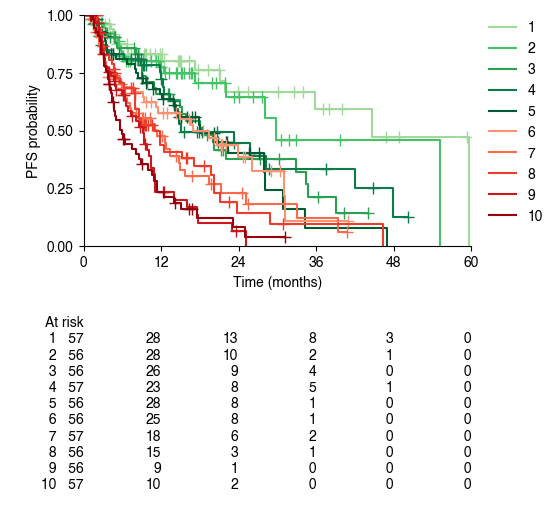

In [10]:
risk_scores = External_predictions.copy()
risk_scores['risk_bin'] = pd.qcut(risk_scores['risk_score'], q=10, labels=False)
risk_scores['risk_bin'] = risk_scores['risk_bin'] + 1
risk_scores = risk_scores.sort_values('risk_bin')
palette_km = {10:'#99000d', 9:'#cb181d', 8:'#ef3b2c', 7:'#fb6a4a', 6:'#fc9272', 5:'#005a32', 4:"#0B7C49", 3:"#2aa051", 2:"#44c366", 1:'#a1d99b'}
plot_kaplan_meier_risktable(risk_scores, 'risk_bin', colors=palette_km, figsize=(5,3), only_risk=True, legend_out=True, upper_limit=60,
                            ylabel = 'PFS probability',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/external/risk_bin_kaplan_meier.pdf'
                            )


**Fig. 3d**

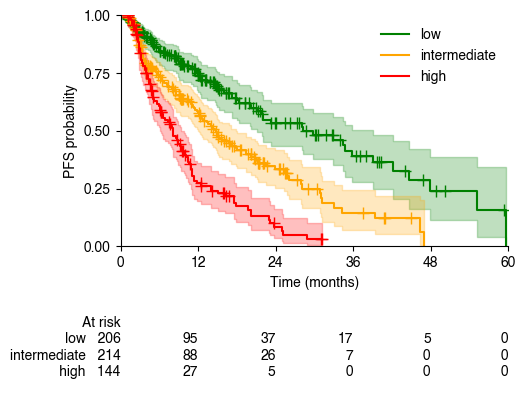

In [11]:
PFS = External_predictions.copy()
PFS['risk_group'] = pd.Categorical(PFS['risk_group'], categories=['low', 'intermediate', 'high'], ordered=True)
PFS = PFS.sort_values('risk_group')
PFS.pipe(plot_kaplan_meier_risktable, 'risk_group', colors = {'high':'red', 'intermediate':'orange', 'low':'green'}, conf_intervals = True,  upper_limit=60, figsize=(5,3), only_risk = True,
         ylabel = 'PFS probability',
        #   save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/external/KM_cinicogenomic.pdf'         
         )

In [12]:
#cindex on tempus
concordance_index_censored(External_predictions['Event'].values.astype(bool), External_predictions['Time'].values, External_predictions.risk_score.values)[0]


np.float64(0.6494410808325213)

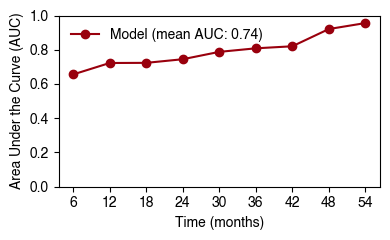

In [13]:
plot_time_dependent_auc_from_scores([External_predictions.risk_score.values], 
                                    ['Model'], 
                                    y_forSurv(y_msk), 
                                    y_forSurv(External_predictions[['Time', 'Event']]), 
                                    times=np.arange(6, 60, 6), 
                                    figsize=(4,2.5), 
                                    ylim=(0, 1), 
                                    grid = False,
                                    palette = {'Model': '#99000d'},
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/time_dependent_auc_clinicogenomic_tempus.pdf'
)

**Fig. 3e**

Chi-Square Test p-value: 0.001053532220068956


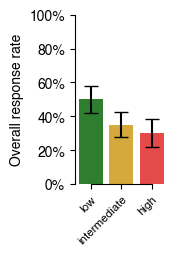

In [14]:
orr = Ext_CDK_extended_features.response_rollup.str.split('/', expand=True)[0].dropna().apply(lambda x: x in ['Partial Response', 'Complete Response']).astype(int).to_frame('ORR')
contingency_table = orr.merge(External_predictions[['risk_group']], left_index=True, right_index=True)

from statsmodels.stats.proportion import proportion_confint
table = pd.crosstab(contingency_table['ORR'], contingency_table['risk_group'])
table.index = ['No_Response', 'Response']
from scipy.stats import chi2_contingency
chi2, p, dof, exp = chi2_contingency(table)
print(f'Chi-Square Test p-value: {p}')

#95% CI using Clopper-Pearson method
ci_high = proportion_confint(count=table.loc['Response', 'high'], nobs=table['high'].sum(), method='beta')
ci_intermediate = proportion_confint(count=table.loc['Response', 'intermediate'], nobs=table['intermediate'].sum(), method='beta')
ci_low = proportion_confint(count=table.loc['Response', 'low'], nobs=table['low'].sum(), method='beta')

contingency_table = pd.DataFrame({
    'risk_group': ['high', 'intermediate', 'low'],
    'ORR': [table.loc['Response', 'high'] / table['high'].sum(),
            table.loc['Response', 'intermediate'] / table['intermediate'].sum(),
            table.loc['Response', 'low'] / table['low'].sum()],
    'CI_Lower': [ci_high[0], ci_intermediate[0], ci_low[0]],
    'CI_Upper': [ci_high[1], ci_intermediate[1], ci_low[1]]
})

contingency_table = contingency_table.set_index('risk_group').loc[['low', 'intermediate', 'high']].reset_index()

#barplot with error bars
plt.figure(figsize=(1.2, 2.2))
sns.barplot(x='risk_group', y='ORR', data=contingency_table, hue='risk_group', palette=palette, errorbar=None)
plt.errorbar(x=[0, 1, 2], y=contingency_table['ORR'], yerr=[contingency_table['ORR'] - contingency_table['CI_Lower'], contingency_table['CI_Upper'] - contingency_table['ORR']], fmt='none', c='black', capsize=5)
plt.ylim(0, 1)
plt.ylabel('Overall response rate')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
sns.despine(trim = True)
plt.xticks(fontsize = 'small', rotation = 45, ha = 'right', rotation_mode = 'anchor')
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/orr_by_risk_group_tempus.pdf', bbox_inches='tight')
plt.show()

### Subgroup analyses

**Fig. 3h**

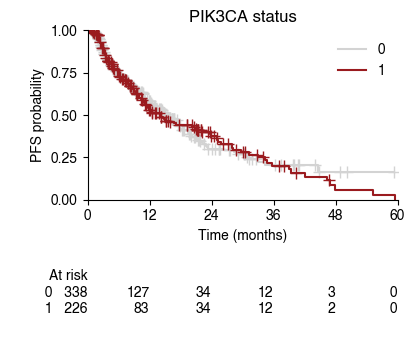

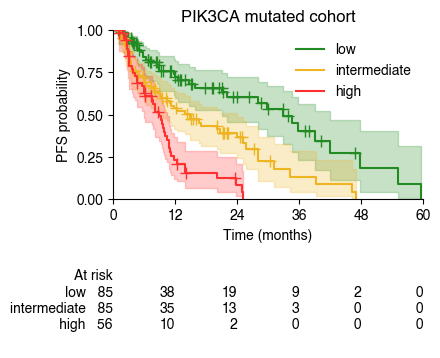

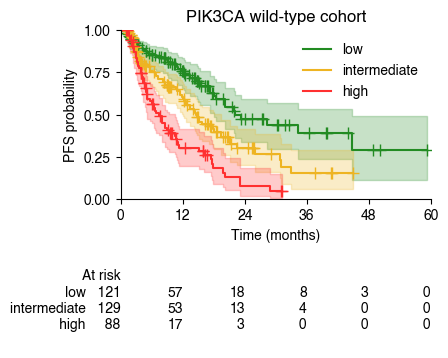

In [15]:
pik3ca = PFS.merge(Ext_CDK[['PIK3CA_mut']], left_index = True, right_index = True)
pik3ca['risk_group'] = pd.Categorical(pik3ca['risk_group'], categories=['low', 'intermediate', 'high'], ordered=True)
pik3ca = pik3ca.sort_values('risk_group')
pik3ca.pipe(plot_kaplan_meier_risktable, 'PIK3CA_mut', colors = {1:'#9a1b1f', 0:'lightgray'}, conf_intervals = False, only_risk=True, title = 'PIK3CA status' , upper_limit=60, 
ylabel = 'PFS probability',
            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/pik3ca_status.pdf',
            figsize=(4, 2.2))
pik3ca.query('PIK3CA_mut == 1').pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True, only_risk=True,title = 'PIK3CA mutated cohort', upper_limit=60,
                                     ylabel = 'PFS probability', 
# save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/pik3ca_mut.pdf',
figsize=(4, 2.2))
pik3ca.query('PIK3CA_mut == 0').pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True, only_risk=True, title = 'PIK3CA wild-type cohort', upper_limit=60, 
ylabel = 'PFS probability', 
# save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/pik3ca_wildtype.pdf',
figsize=(4, 2.2))


**Fig. 3g**

In [16]:
liquid_only = Ext_CDK_panel.loc[lambda x: x.Assay.str.contains('xF')]

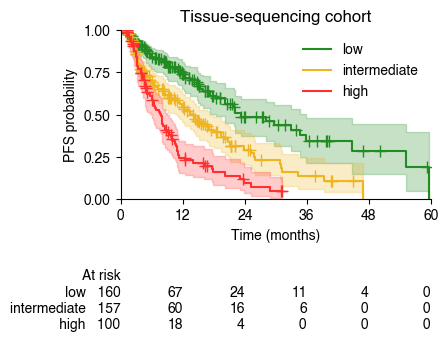

In [17]:
PFS.query('index not in @liquid_only.index').pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True, title = 'Tissue-sequencing cohort',
                                                # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/tissue_sequencing.pdf', 
                                                  upper_limit=60, figsize=(4, 2.2), only_risk=True, ylabel = 'PFS probability')

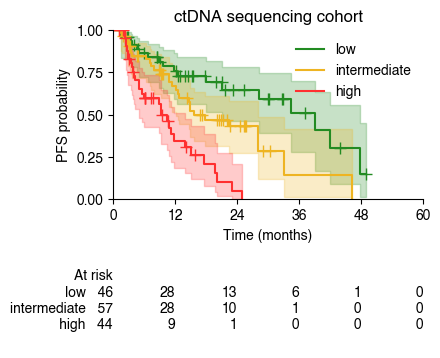

In [18]:
PFS.query('index in @liquid_only.index').pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True, title = 'ctDNA sequencing cohort', 
                                            #   save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/ctdna_sequencing.pdf',
                                              upper_limit=60, figsize=(4, 2.2), only_risk=True, ylabel = 'PFS probability')

**Subgroup analysis**

In [19]:
### MSK cohort
msk_extended_clinical['risk_group'] = CDKPredict.get_train_risk_groups_3().to_frame()
msk_subgroup = pd.concat([msk_extended_clinical, clinical], axis = 1)

#MSK
msk_subgroup = msk_subgroup[['risk_group','fulvestrant',  'regimen', 'bone_only', 'liver', 'de_novo_met', 'age_met_under_50','tfi_under_12months']]\
.assign(
        Abemaciclib = lambda x: [1 if 'abema' in str(treatment).lower() else 0 for treatment in x.regimen],
        Ribociclib = lambda x: [1 if 'ribo' in str(treatment).lower() else 0 for treatment in x.regimen],
        Palbociclib = lambda x: [1 if 'palbo' in str(treatment).lower() else 0 for treatment in x.regimen], 
        Aromatase_inhibitor = lambda x: [1 if fulvestrant == 0 else 0 for fulvestrant in x.fulvestrant], 
        Ex_novo = lambda x: [1 if de_novo_met == 1 else 0 for de_novo_met in x.de_novo_met], 
        tfi_over_12months = lambda x: [1 if tfi_under_12months == 0 else 0 for tfi_under_12months in x.tfi_under_12months],
        no_liver = lambda x: [1 if liver == 0 else 0 for liver in x.liver], 
        no_bone_only = lambda x: [1 if bone_only == 0 else 0 for bone_only in x.bone_only], 
        age_met_over_50 = lambda x: [1 if age_met_under_50 == 0 else 0 for age_met_under_50 in x.age_met_under_50])\
        .drop(columns = 'regimen')

#EXT_CDK
ext_subgroup = Ext_CDK_extended_features.drop(columns = 'bone_only')\
    .merge(PFS[['risk_group']], left_index = True, right_index = True)\
        .rename(columns = {'palbo_flag':'Palbociclib', 'ribo_flag':'Ribociclib', 'abema_flag':'Abemaciclib'})\
.merge(Ext_CDK.loc[:, 'tmb_10_plus':'age_invasive_under_50'], left_index = True, right_index = True)\
            .assign(
                    Aromatase_inhibitor = lambda x: [1 if fulvestrant == 0 else 0 for fulvestrant in x.fulvestrant],
                    Ex_novo = lambda x: [1 if de_novo_met == 1 else 0 for de_novo_met in x.de_novo_met], 
                    tfi_over_12months = lambda x: [1 if tfi_under_12months == 0 else 0 for tfi_under_12months in x.tfi_under_12months],
                    no_liver = lambda x: [1 if liver == 0 else 0 for liver in x.liver], 
                    no_bone_only = lambda x: [1 if bone_only == 0 else 0 for bone_only in x.bone_only],
                    age_met_over_50 = lambda x: [1 if age_met_under_50 == 0 else 0 for age_met_under_50 in x.age_met_under_50])
                
ext_subgroup =ext_subgroup.loc[:, msk_subgroup.columns]

unified_subgroup = pd.concat([
ext_subgroup.assign(cohort = 'ext'), 
msk_subgroup.assign(cohort = 'msk')
])

#add time and event
unified_subgroup = unified_subgroup.merge(pd.concat([Ext_CDK[['Time', 'Event']], y_msk]), left_index = True, right_index = True)
unified_subgroup['risk_group'] = pd.Categorical(unified_subgroup['risk_group'], categories = ['low', 'intermediate', 'high'], ordered = True)
unified_subgroup = unified_subgroup.sort_values('risk_group')                


In [20]:
res = []
for col in [col for col in unified_subgroup.columns if col not in ['Time', 'Event', 'risk_group', 'cohort']]:
    for cohort in ['msk', 'ext']:
        df_cox = unified_subgroup.loc[unified_subgroup.cohort == cohort, [col, 'Time', 'Event', 'risk_group']]
        df_cox = df_cox.loc[df_cox[col] == 1, :].drop(columns = col)
        df_cox['risk_group'] = pd.Categorical(df_cox['risk_group'], categories=['low', 'intermediate', 'high'], ordered=True)
        df_cox = df_cox.sort_values('risk_group')
        stats = cox_regression(df_cox)
        high_vs_low = stats.loc[stats.index.str.contains('high'), :]
        intermediate_vs_low = stats.loc[stats.index.str.contains('intermediate'), :]
        nr_high = df_cox.query('risk_group == "high"').shape[0]
        nr_intermediate = df_cox.query('risk_group == "intermediate"').shape[0]
        res.append({'HR' : high_vs_low['hazard_ratio'].values[0], 'CI_lower': high_vs_low['ci_lower_95'].values[0], 'CI_upper': high_vs_low['ci_upper_95'].values[0], 'p': high_vs_low['p_value'].values[0], 'group':'high', 'cohort': cohort, 'variable': col, 'nr': nr_high})
        res.append({'HR' : intermediate_vs_low['hazard_ratio'].values[0], 'CI_lower': intermediate_vs_low['ci_lower_95'].values[0], 'CI_upper': intermediate_vs_low['ci_upper_95'].values[0], 'p': intermediate_vs_low['p_value'].values[0], 'group':'intermediate', 'cohort': cohort, 'variable': col, 'nr': nr_intermediate})
res = pd.DataFrame(res)

**Supplementary Table 7**

In [21]:
save_df = res.assign(cohort = ['external' if i == 'ext' else i for i in res.cohort])\
    .query('variable in ["Abemaciclib", "Ribociclib", "Palbociclib", "Aromatase_inhibitor", "fulvestrant"]')[['variable'] + ['HR', 'CI_lower', 'CI_upper', 'p', 'group', 'cohort', 'nr']]
# save_df.to_csv('/scratch/razavip/boscoll/cdk_predict/results/tables/treatment_table.csv', index=False)
save_df

,variable,HR,CI_lower,CI_upper,p,group,cohort,nr
0,fulvestrant,3.5179,2.4888,4.9725,1.048563e-12,high,msk,134
1,fulvestrant,1.8686,1.3177,2.6499,4.517481e-04,intermediate,msk,144
2,fulvestrant,3.0906,1.8323,5.2131,2.334955e-05,high,external,65
3,fulvestrant,1.5001,0.8911,2.5251,1.269699e-01,intermediate,external,75
24,Abemaciclib,4.9254,2.9020,8.3596,3.479509e-09,high,msk,47
25,Abemaciclib,2.7158,1.6431,4.4890,9.752377e-05,intermediate,msk,75
26,Abemaciclib,3.9160,1.6940,9.0526,1.408845e-03,high,external,27
27,Abemaciclib,2.6885,1.2354,5.8506,1.267158e-02,intermediate,external,40
28,Ribociclib,5.8645,3.3372,10.3058,7.773491e-10,high,msk,27
29,Ribociclib,1.8607,1.1347,3.0511,1.386365e-02,intermediate,msk,61


**Fig 3f**

/tmp/ipykernel_1037896/2928600835.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=['msk', 'ext'], ordered=True)


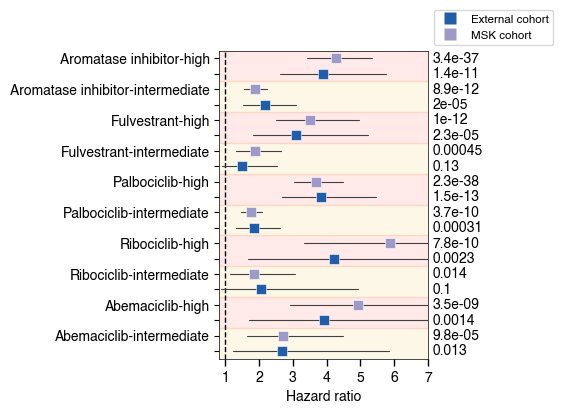

In [22]:
plot_df = res.query('variable in ["Abemaciclib", "Ribociclib", "Palbociclib", "Aromatase_inhibitor", "fulvestrant"]')
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=['msk', 'ext'], ordered=True)
plot_df = plot_df.sort_values(['cohort'])
plot_df['feature'] = [
                   'Aromatase inhibitor' if i == 'Aromatase_inhibitor' else 
                   'Fulvestrant' if i == 'fulvestrant' else 
                   'Palbociclib' if i == 'Palbociclib' else
                   'Ribociclib' if i == 'Ribociclib' else
                   'Abemaciclib' if i == 'Abemaciclib' else i for i in plot_df['variable']]
plot_df['feature'] = plot_df['feature'] + '-' + plot_df['group']
feature_order = ['Aromatase inhibitor-high', 'Aromatase inhibitor-intermediate', 'Fulvestrant-high', 'Fulvestrant-intermediate', 'Palbociclib-high', 'Palbociclib-intermediate', 'Ribociclib-high', 
                 'Ribociclib-intermediate', 'Abemaciclib-high', 'Abemaciclib-intermediate']
plot_df['feature'] = pd.Categorical(plot_df['feature'], categories = feature_order, ordered = True)
plot_df = plot_df.sort_values(['feature', 'cohort'])
plot_df['feature'] = plot_df['feature'].astype(str)


# #remove second occurrence of features to keep only one gene name in the row
plot_df.loc[plot_df['feature'].duplicated(), 'feature'] = ''

# position and palette
ypos = np.arange(len(plot_df))  # one y per row
plot_df['ypos'] = ypos

palette = {'ext': '#225ea8',      
           'msk': '#9e9ac8'}   

fig, ax = plt.subplots(figsize=(3,4))

# light alternating background bands 
for i in range(0, len(plot_df), 4):
    ax.axhspan(i-0.5, i+1.5, color='#FF3030', zorder=0, alpha = 0.1)
#other band as #EEB422
for i in range(2, len(plot_df), 4):
    ax.axhspan(i-0.5, i+1.5, color='#EEB422', zorder=0, alpha = 0.1)
ax.axvline(1, ls='--', lw=1, color='black', zorder=1)


for _, r in plot_df.iterrows():
    # CI bar
    ax.plot([r['CI_lower'], r['CI_upper']], [r['ypos'], r['ypos']],
            color='0.25', lw=0.8, solid_capstyle='round', zorder=2)
    # square marker at HR
    ax.scatter(r['HR'], r['ypos'],
               s=50, marker='s',
               color=palette.get(r['cohort'], '#034e7b'),
               edgecolor='white', linewidth=0.4,
               zorder=3)

# y axis
ax.set_yticks(ypos)
ax.set_ylim(-0.5, len(plot_df)-0.5)
ax.set_yticklabels(plot_df['feature'])
# for ticklabel, feature in zip(ax.get_yticklabels(), plot_df['feature']):
#     if 'high' in str(feature):
#         ticklabel.set_color('#9a1b1f')
#     else:
#         ticklabel.set_color('#EEB422')
ax.invert_yaxis()  
ax.grid(False)


# x axis
ax.set_xticks([0.5, 1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels([0.5, 1, 2, 3, 4, 5, 6, 7])
ax.tick_params(axis='x',
               which='major',
               bottom=True, top=False,    
               length=5, width=1,         
               direction='out')
ax.set_xlabel('Hazard ratio')
xmin = max(0.1, plot_df['CI_lower'].min()*0.95)
# xmax = plot_df['CI_upper'].max()*1.05
xmax = 7
ax.set_xlim(xmin, xmax)

# major axis
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')


ax.set_xlabel('Hazard ratio')
ax.set_ylabel('')

# p values
for _, r in plot_df.iterrows():
    ax.text(xmax*1.02, r['ypos'], f"{r['p']:.2g}",
            va='center', ha='left',
            )

plt.subplots_adjust(right=0.82)

# legend
from matplotlib.lines import Line2D
square = dict(linestyle='None', marker='s', markersize=8, markeredgecolor='none')
handles = [
    Line2D([0], [0], **square, markerfacecolor=palette['ext'],  label='External'),
    Line2D([0], [0], **square, markerfacecolor=palette['msk'], label='MSK'),
]
ax.legend(handles=handles,
          frameon=True, 
          fontsize='small',
            bbox_to_anchor=(1, 1), 
            labels = ['External cohort', 'MSK cohort']
          )

# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/subgroup_treatment.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1037896/182637668.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=['msk', 'ext'], ordered=True)


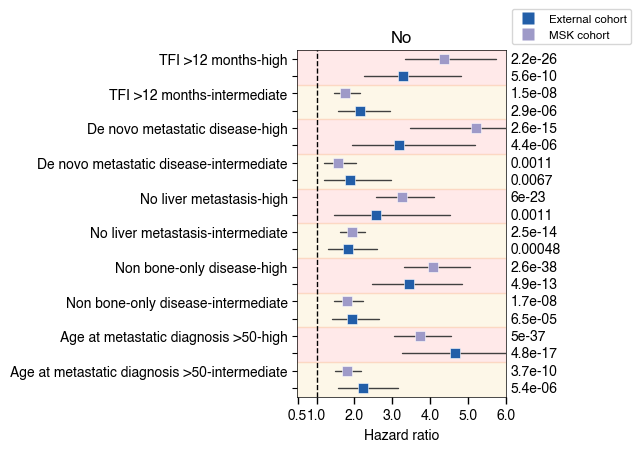

In [23]:
#positive prognostic
plot_df = res.query('variable in ["de_novo_met", "tfi_over_12months", "no_bone_only", "no_liver", "age_met_over_50"]')
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=['msk', 'ext'], ordered=True)
plot_df = plot_df.sort_values(['cohort'])
plot_df['feature'] = [
                   'De novo metastatic disease' if i == 'de_novo_met' else 
                   'Ex-novo metastatic disease' if i == 'ex_novo' else
                   'TFI ≤12 months' if i == 'tfi_under_12months' else 
                   'TFI >12 months' if i == 'tfi_over_12months' else
                   'Bone-only disease' if i == 'bone_only' else 
                   'Non bone-only disease' if i == 'no_bone_only' else
                   'Liver metastasis' if i == 'liver' else 
                   'No liver metastasis' if i == 'no_liver' else
                   'Age at metastatic diagnosis ≤50' if i == 'age_met_under_50' else 
                   'Age at metastatic diagnosis >50' if i == 'age_met_over_50' else i for i in plot_df['variable']]
plot_df['feature'] = plot_df['feature'] + '-' + plot_df['group']
feature_order = [
                 'TFI ≤12 months-high', 'TFI ≤12 months-intermediate', 'TFI >12 months-high', 'TFI >12 months-intermediate', 
                 'De novo metastatic disease-high', 'De novo metastatic disease-intermediate', 'Ex-novo metastatic disease-high', 'Ex-novo metastatic disease-intermediate', 
                 'Liver metastasis-high', 'Liver metastasis-intermediate', 'No liver metastasis-high', 'No liver metastasis-intermediate', 
                 'Bone-only disease-high', 'Bone-only disease-intermediate', 'Non bone-only disease-high', 'Non bone-only disease-intermediate',
                 'Age at metastatic diagnosis ≤50-high', 'Age at metastatic diagnosis ≤50-intermediate', 'Age at metastatic diagnosis >50-high', 'Age at metastatic diagnosis >50-intermediate']
plot_df['feature'] = pd.Categorical(plot_df['feature'], categories = feature_order, ordered = True)
plot_df = plot_df.sort_values(['feature', 'cohort'])
plot_df['feature'] = plot_df['feature'].astype(str)


# #remove second occurrence of features to keep only one gene name in the row
plot_df.loc[plot_df['feature'].duplicated(), 'feature'] = ''

# position and palette
ypos = np.arange(len(plot_df))  # one y per row
plot_df['ypos'] = ypos

palette = {'ext': '#225ea8',      
           'msk': '#9e9ac8'}   

fig, ax = plt.subplots(figsize=(3,4.5))

# light alternating background bands 
for i in range(0, len(plot_df), 4):
    ax.axhspan(i-0.5, i+1.5, color='#FF3030', zorder=0, alpha = 0.1)
#other band as #EEB422
for i in range(2, len(plot_df), 4):
    ax.axhspan(i-0.5, i+1.5, color='#EEB422', zorder=0, alpha = 0.1)
ax.axvline(1, ls='--', lw=1, color='black', zorder=1)


for _, r in plot_df.iterrows():
    # CI bar
    ax.plot([r['CI_lower'], r['CI_upper']], [r['ypos'], r['ypos']],
            color='0.25', lw=1, solid_capstyle='round', zorder=2)
    # square marker at HR
    ax.scatter(r['HR'], r['ypos'],
               s=50, marker='s', 
               color=palette.get(r['cohort'], '#034e7b'),
               edgecolor='white', linewidth=0.4,
               zorder=3)

# y axis
ax.set_yticks(ypos)
ax.set_ylim(-0.5, len(plot_df)-0.5)
ax.set_yticklabels(plot_df['feature'])
# for ticklabel, feature in zip(ax.get_yticklabels(), plot_df['feature']):
#     if 'high' in str(feature):
#         ticklabel.set_color('#9a1b1f')
#     else:
#         ticklabel.set_color('#EEB422')
ax.invert_yaxis()  
ax.grid(False)


# x axis
ax.set_xticks([0.5, 1, 2, 3, 4, 5, 6])
ax.tick_params(axis='x',
               which='major',
               bottom=True, top=False,    
               length=5, width=1,         
               direction='out')
ax.set_xlabel('Hazard ratio')
xmin = max(0.1, 0.49)
xmax = 6
ax.set_xlim(xmin, xmax)

# major axis
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')


ax.set_xlabel('Hazard ratio')
ax.set_ylabel('')

# p values
for _, r in plot_df.iterrows():
    ax.text(xmax*1.02, r['ypos'], f"{r['p']:.2g}",
            va='center', ha='left',
            )

plt.subplots_adjust(right=0.82)

# legend
from matplotlib.lines import Line2D
square = dict(linestyle='None', marker='s', markersize=8, markeredgecolor='none')
handles = [
    Line2D([0], [0], **square, markerfacecolor=palette['ext'],  label='External'),
    Line2D([0], [0], **square, markerfacecolor=palette['msk'], label='MSK'),
]
ax.legend(handles=handles,
          frameon=True, 
          fontsize='small',
            bbox_to_anchor=(1, 1),
            labels = ['External cohort', 'MSK cohort']
          )
plt.title('No', fontweight = 'bold')
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/subgroup_cox_positive_prognostic.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1037896/1547290136.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=['msk', 'ext'], ordered=True)


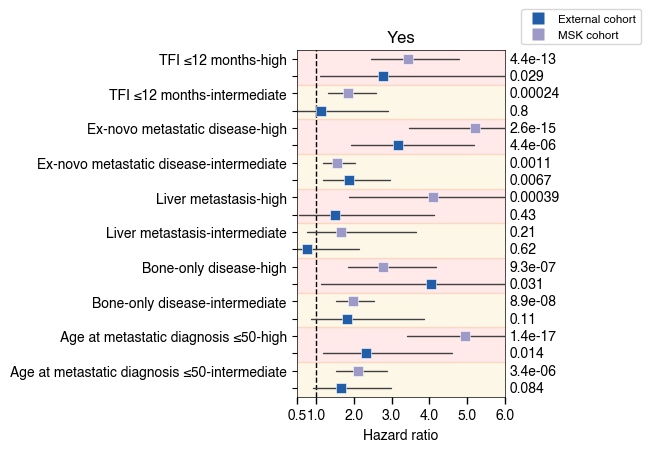

In [24]:
#negative prognostic
plot_df = res.query('variable in ["Ex_novo", "tfi_under_12months", "bone_only", "liver", "age_met_under_50"]')
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=['msk', 'ext'], ordered=True)
plot_df = plot_df.sort_values(['cohort'])
plot_df['feature'] = [
                   'De novo metastatic disease' if i == 'de_novo_met' else 
                   'Ex-novo metastatic disease' if i == 'Ex_novo' else
                   'TFI ≤12 months' if i == 'tfi_under_12months' else 
                   'TFI >12 months' if i == 'tfi_over_12months' else
                   'Bone-only disease' if i == 'bone_only' else 
                   'Non bone-only disease' if i == 'no_bone_only' else
                   'Liver metastasis' if i == 'liver' else 
                   'No liver metastasis' if i == 'no_liver' else
                   'Age at metastatic diagnosis ≤50' if i == 'age_met_under_50' else 
                   'Age at metastatic diagnosis >50' if i == 'age_met_over_50' else i for i in plot_df['variable']]
plot_df['feature'] = plot_df['feature'] + '-' + plot_df['group']
feature_order = [
                 'TFI ≤12 months-high', 'TFI ≤12 months-intermediate', 'TFI >12 months-high', 'TFI >12 months-intermediate', 
                 'De novo metastatic disease-high', 'De novo metastatic disease-intermediate', 'Ex-novo metastatic disease-high', 'Ex-novo metastatic disease-intermediate', 
                 'Liver metastasis-high', 'Liver metastasis-intermediate', 'No liver metastasis-high', 'No liver metastasis-intermediate', 
                 'Bone-only disease-high', 'Bone-only disease-intermediate', 'Non bone-only disease-high', 'Non bone-only disease-intermediate',
                 'Age at metastatic diagnosis ≤50-high', 'Age at metastatic diagnosis ≤50-intermediate', 'Age at metastatic diagnosis >50-high', 'Age at metastatic diagnosis >50-intermediate']
plot_df['feature'] = pd.Categorical(plot_df['feature'], categories = feature_order, ordered = True)
plot_df = plot_df.sort_values(['feature', 'cohort'])
plot_df['feature'] = plot_df['feature'].astype(str)


# #remove second occurrence of features to keep only one gene name in the row
plot_df.loc[plot_df['feature'].duplicated(), 'feature'] = ''

# position and palette
ypos = np.arange(len(plot_df))  # one y per row
plot_df['ypos'] = ypos

palette = {'ext': '#225ea8',      
           'msk': '#9e9ac8'}   

fig, ax = plt.subplots(figsize=(3,4.5))

# light alternating background bands 
for i in range(0, len(plot_df), 4):
    ax.axhspan(i-0.5, i+1.5, color='#FF3030', zorder=0, alpha = 0.1)
#other band as #EEB422
for i in range(2, len(plot_df), 4):
    ax.axhspan(i-0.5, i+1.5, color='#EEB422', zorder=0, alpha = 0.1)
ax.axvline(1, ls='--', lw=1, color='black', zorder=1)


for _, r in plot_df.iterrows():
    # CI bar
    ax.plot([r['CI_lower'], r['CI_upper']], [r['ypos'], r['ypos']],
            color='0.25', lw=1, solid_capstyle='round', zorder=2)
    # square marker at HR
    ax.scatter(r['HR'], r['ypos'],
               s=50, marker='s', 
               color=palette.get(r['cohort'], '#034e7b'),
               edgecolor='white', linewidth=0.4,
               zorder=3)

# y axis
ax.set_yticks(ypos)
ax.set_ylim(-0.5, len(plot_df)-0.5)
ax.set_yticklabels(plot_df['feature'])
# for ticklabel, feature in zip(ax.get_yticklabels(), plot_df['feature']):
#     if 'high' in str(feature):
#         ticklabel.set_color('#9a1b1f')
#     else:
#         ticklabel.set_color('#EEB422')
ax.invert_yaxis()  
ax.grid(False)


# x axis
ax.set_xticks([0.5, 1, 2, 3, 4, 5, 6])
ax.tick_params(axis='x',
               which='major',
               bottom=True, top=False,    
               length=5, width=1,         
               direction='out')
ax.set_xlabel('Hazard ratio')
xmin = 0.49
xmax = 6
ax.set_xlim(xmin, xmax)

# major axis
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')


ax.set_xlabel('Hazard ratio')
ax.set_ylabel('')

# p values
for _, r in plot_df.iterrows():
    ax.text(xmax*1.02, r['ypos'], f"{r['p']:.2g}",
            va='center', ha='left',
            )

plt.subplots_adjust(right=0.82)

# legend
from matplotlib.lines import Line2D
square = dict(linestyle='None', marker='s', markersize=8, markeredgecolor='none')
handles = [
    Line2D([0], [0], **square, markerfacecolor=palette['ext'],  label='Tempus'),
    Line2D([0], [0], **square, markerfacecolor=palette['msk'], label='MSK'),
]
plt.title('Yes')
ax.legend(handles=handles,
          frameon=True, 
          fontsize='small',
            bbox_to_anchor=(1.05, 1), 
            labels = ['External cohort', 'MSK cohort']
          )

mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/subgroup_cox_negative_prognostic.pdf', bbox_inches='tight')
plt.show()

#### ≤12 months TFI criteria

In [25]:
PFS = pd.concat([PFS, Ext_CDK[['tfi_under_12months']]], axis = 1)

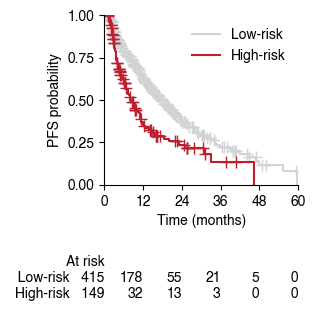

In [26]:
plot_kaplan_meier_risktable(PFS.assign(tfi_under_12months = ['High-risk' if i == 1 else 'Low-risk' for i in PFS.tfi_under_12months]), 'tfi_under_12months', colors= {'High-risk':'#be1e2d', 'Low-risk':'#d1d3d4'}, figsize=(2.5,2.2), only_risk=True,
                            ylabel = 'PFS probability',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/inavo_criteria_tempus.pdf', 
)

**Fig. 3i**

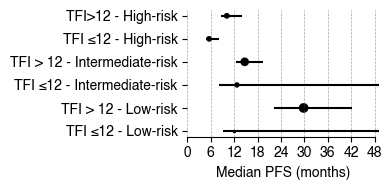

In [27]:
plot_df = pd.DataFrame({
    'risk_group': ['TFI>12 - High-risk', 'TFI ≤12 - High-risk', 'TFI > 12 - Intermediate-risk', 'TFI ≤12 - Intermediate-risk', 'TFI > 12 - Low-risk', 'TFI ≤12 - Low-risk'],
    'mPFS' : [10.1, 5.59, 14.7, 12.69,29.8, 11.93],
    'upper_CI' : [13.9, 7.99, 19.5, 60, 42.1, 60],
    'lower_CI' : [8.51, 4.73, 12.39, 8.19, 22.09, 9.07], 
    'nr' : [73, 71, 151, 63, 191, 15]
})
plot_df = plot_df.iloc[::-1]

#forestplot with mPFS and conf int 
plt.figure(figsize=(4, 2))
plt.errorbar(x=plot_df['mPFS'], y=plot_df['risk_group'], 
             xerr=[plot_df['mPFS'] - plot_df['lower_CI'], 
                    plot_df['upper_CI'] - plot_df['mPFS']], fmt='o', color='black', ecolor='black', capsize=0,
                      markersize=1.5)
#normalize between 200 and 10 
min_marker = 1
max_marker = 50
s_scaled = (plot_df['nr'] - 15) / (200 - 10)
s_scaled = s_scaled * (max_marker - min_marker) + min_marker
plt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.scatter(x=plot_df['mPFS'], y=plot_df['risk_group'], color='black', s=s_scaled, marker='o', linewidths=0.2)
plt.xlabel('Median PFS (months)')
plt.ylabel('')
plt.xlim(0, 49)
plt.xticks([0, 6, 12, 18, 24, 30, 36, 42, 48])
plt.tight_layout()
sns.despine(trim = True, left = True)
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/inavo_forestplot.pdf', bbox_inches='tight')
plt.show()



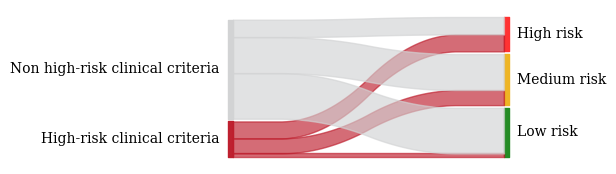

In [ ]:
# from pySankey.sankey import sankey

# # 1. Create temporary columns with the exact labels you want on the plot
# PFS['inavo_label'] = PFS['inavo_criteria'].map({1: 'High-risk clinical criteria', 0: 'Non high-risk clinical criteria'})
# PFS['inavo_label'] = pd.Categorical(PFS['inavo_label'], categories=['High-risk clinical criteria', 'Non high-risk clinical criteria'], ordered=True)
# PFS['risk_label'] = PFS['risk_group'].map({'low': 'Low risk', 'medium': 'Medium risk', 'high': 'High risk'})
# PFS['risk_label'] = pd.Categorical(PFS['risk_label'], categories=['Low risk', 'Medium risk', 'High risk'], ordered=True)
# PFS = PFS.sort_values(['inavo_label', 'risk_label'])

# color_dict = {
#     'High-risk clinical criteria': '#be1e2d',
#     'Non high-risk clinical criteria': '#d2d3d4',
#     'Low risk': '#228B22',
#     'Medium risk': '#EEB422',
#     'High risk': '#FF3030'
# }

# # 3. Generate the Sankey diagram
# sankey(
#     left=PFS['inavo_label'], 
#     right=PFS['risk_label'], 
#     colorDict=color_dict, 
#     fontsize=10
# )

# fig = plt.gcf()
# fig.set_size_inches(4, 2) 

# # plt.savefig("/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/inavo_sankey_tempus.pdf", bbox_inches='tight')
# plt.show()

***Running the below cells requires the Python package rpy2, and R packages survival***

In [28]:
%load_ext rpy2.ipython

In [29]:
%%R
library(survival)

In [30]:
%%R -i PFS
fit = survfit(Surv(Time, Event) ~ tfi_under_12months, data = PFS)
summary(fit, times = c(12, 24))

Call: survfit(formula = Surv(Time, Event) ~ tfi_under_12months, data = PFS)

                tfi_under_12months=0 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   12    178     130    0.631  0.0262        0.582        0.685
   24     55

      56    0.371  0.0319        0.314        0.439

                tfi_under_12months=1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   12     32      80    0.346  0.0455        0.267        0.448
   24     13       8    0.237  0.0454        0.162        0.345



In [31]:
twelve_month_criteria = pd.DataFrame({
    'risk_group': ['high', 'low'],
    'PFS_12_months': [0.346, 0.631],
    'CI_Lower': [0.267, 0.582],
    'CI_Upper': [0.448, 0.685] 
})
twentyfour_month_criteria = pd.DataFrame({
    'risk_group': ['high', 'low'],
    'PFS_24_months': [0.237, 0.371],
    'CI_Lower': [0.162, 0.314],
    'CI_Upper': [0.345, 0.439] 
})

In [32]:
%%R -i PFS
fit = survfit(Surv(Time, Event) ~ risk_group, data = PFS)
summary(fit, times = c(12, 24))

Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = PFS)

                risk_group=low 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   12     95      43    0.744  0.0344        0.680        0.815
   24     37      20    0.534  0.0479        0.448        0.637

                risk_group=intermediate 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   12     88      79    0.578  0.0369        0.510        0.655
   24     26      30    0.334  0.0415        0.262        0.426

                risk_group=high 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   12     27      88   0.2744  0.0426       0.2025        0.372
   24      5      14   0.0846  0.0322       0.0402        0.178



In [33]:
twelve_month_cdkpredict = pd.DataFrame({
    'risk_group': ['high', 'intermediate', 'low'],
    'PFS_12_months': [0.2744, 0.578,  0.744],
    'CI_Lower': [0.2025, 0.510, 0.680],
    'CI_Upper': [0.372, 0.655, 0.815] 
})
twentyfour_month_cdkpredict  = pd.DataFrame({
    'risk_group': ['high', 'intermediate', 'low'],
    'PFS_24_months': [0.0846, 0.334, 0.534],
    'CI_Lower': [0.0402, 0.262, 0.448],
    'CI_Upper': [0.178, 0.426, 0.637] 
})

**Fig. 3j**

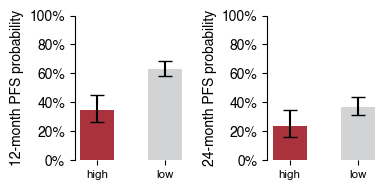

In [34]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 2))
sns.barplot(x='risk_group', y='PFS_12_months', data=twelve_month_criteria, hue='risk_group', palette={'high':'#be1e2d', 'low':'#d2d3d4'}, errorbar=None, ax=ax1, width=0.5)
ax1.errorbar(x=[0, 1], y=twelve_month_criteria['PFS_12_months'], yerr=[twelve_month_criteria['PFS_12_months'] - twelve_month_criteria['CI_Lower'], twelve_month_criteria['CI_Upper'] - twelve_month_criteria['PFS_12_months']], fmt='none', c='black', capsize=5)
ax1.set_ylim(0, 1)
ax1.set_ylabel('12-month PFS probability')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax1.tick_params(axis='x', labelsize='small')
sns.barplot(x='risk_group', y='PFS_24_months', data=twentyfour_month_criteria, hue='risk_group', palette={'high':'#be1e2d', 'low':'#d2d3d4'}, errorbar=None, ax=ax2, width=0.5)
ax2.errorbar(x=[0, 1], y=twentyfour_month_criteria['PFS_24_months'], yerr=[twentyfour_month_criteria['PFS_24_months'] - twentyfour_month_criteria['CI_Lower'], twentyfour_month_criteria['CI_Upper'] - twentyfour_month_criteria['PFS_24_months']], fmt='none', c='black', capsize=5)
ax2.set_ylim(0, 1)
ax2.set_ylabel('24-month PFS probability')
ax2.set_xlabel('')
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
sns.despine(trim = True, bottom = True)
ax2.tick_params(axis='x', labelsize='small')
plt.tight_layout()
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/pfs_rate_inavo.pdf', bbox_inches='tight')
plt.show()

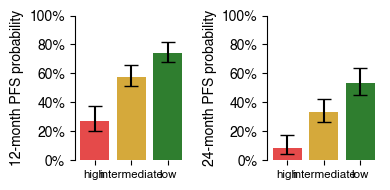

In [35]:
palette = {'high':'#FF3030', 'intermediate':'#EEB422', 'low':'#228B22'}
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 2))
sns.barplot(x='risk_group', y='PFS_12_months', data=twelve_month_cdkpredict, hue='risk_group', palette=palette, errorbar=None, ax=ax1)
ax1.errorbar(x=[0, 1, 2], y=twelve_month_cdkpredict['PFS_12_months'], yerr=[twelve_month_cdkpredict['PFS_12_months'] - twelve_month_cdkpredict['CI_Lower'], twelve_month_cdkpredict['CI_Upper'] - twelve_month_cdkpredict['PFS_12_months']], fmt='none', c='black', capsize=5)
ax1.set_ylim(0, 1)
ax1.set_ylabel('12-month PFS probability')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax1.tick_params(axis='x', labelsize='small')
sns.barplot(x='risk_group', y='PFS_24_months', data=twentyfour_month_cdkpredict, hue='risk_group', palette=palette, errorbar=None, ax=ax2)
ax2.errorbar(x=[0, 1, 2], y=twentyfour_month_cdkpredict['PFS_24_months'], yerr=[twentyfour_month_cdkpredict['PFS_24_months'] - twentyfour_month_cdkpredict['CI_Lower'], twentyfour_month_cdkpredict['CI_Upper'] - twentyfour_month_cdkpredict['PFS_24_months']], fmt='none', c='black', capsize=5)
ax2.set_ylim(0, 1)
ax2.set_ylabel('24-month PFS probability')
ax2.set_xlabel('')
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
sns.despine(trim = True, bottom = True)
ax2.tick_params(axis='x', labelsize='small')
plt.tight_layout()
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/pfs_rate_cdkpredict.pdf', bbox_inches='tight')
plt.show()

***Exploratory analysis MSK cohort TFI > 12 or <12 months***

In [36]:
tfi_msk = CDKPredict.get_train_risk_groups_3().to_frame().join(X_msk[['tfi_under_12months']]).join(y_msk)
tfi_msk['risk_group'] = pd.Categorical(tfi_msk['risk_group'], categories=['low', 'intermediate', 'high'], ordered=True)
tfi_msk = tfi_msk.sort_values('risk_group')

In [37]:
### TFI >12 MONTHS
tfi_high = tfi_msk.query('tfi_under_12months == 0')

**Extended Data Fig. 6d**

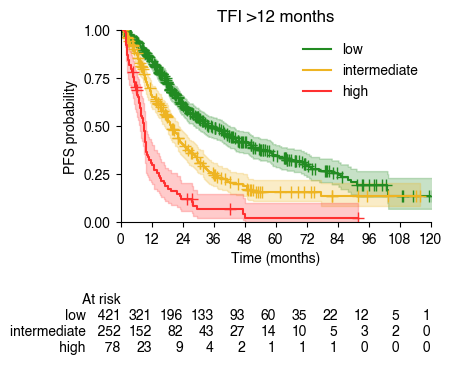

In [38]:
plot_kaplan_meier_risktable(tfi_high, 'risk_group', colors=palette, figsize=(4,2.5), only_risk=True,
                            upper_limit=120,
                            conf_intervals=True,
                            ylabel = 'PFS probability',
                            title = 'TFI >12 months',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/tfi_over_12months_msk.pdf', 
)

In [39]:
### TFI ≤12 MONTHS
tfi_low = tfi_msk.query('tfi_under_12months == 1')
tfi_low = tfi_low.sort_values('risk_group')

**Extended Data Fig. 6d**

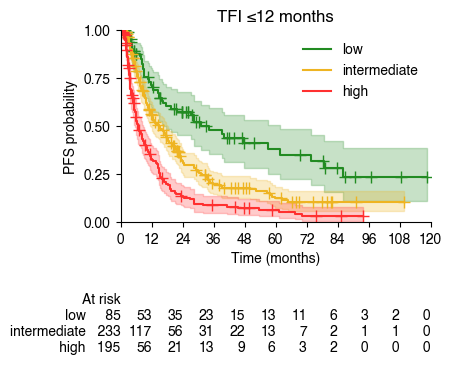

In [40]:
plot_kaplan_meier_risktable(tfi_low, 'risk_group', colors=palette, figsize=(4,2.5), only_risk=True,
                            upper_limit=120,
                            conf_intervals=True,
                            ylabel = 'PFS probability',
                            title = 'TFI ≤12 months',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/tfi_under_12months_msk.pdf', 
)